In [1]:
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_CUDNN_USE_FRONTEND"] = "0"

import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
print("GPUs:", gpus)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Importing the necessary packages

In [2]:
import h5py
import numpy as np
import tensorflow as tf  
import tensorflow as tf
from keras.models import Model
from keras.layers import Input, Conv3D, MaxPooling3D, UpSampling3D, concatenate, BatchNormalization, Activation
from tensorflow.keras import layers as L
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K


In [3]:
#loading the seismic dataset
seismic =  h5py.File('data/seismic.h5','r')
seismic

<HDF5 file "seismic.h5" (mode r)>

In [4]:
X = seismic['cube'][:]
X.shape

(1276, 1760, 1876)

In [ ]:
# splitting the dataset into training and testing sets
il_split = 600
X_train = X[:, :il_split, :, :]
X_test = X[:, il_split:, :, :]
X_train.shape, X_test.shape

In [5]:
#Loading the labels
label = h5py.File('data/salt.h5', 'r')
label

<HDF5 file "salt.h5" (mode r)>

In [6]:
y = label['cube'][:]
y.shape

(1276, 1760, 1876)

In [ ]:
# splitting the labels into training and testing sets
y_train = y[:il_split,:,:]
y_test = y[il_split:,:,:]
y_train.shape, y_test.shape

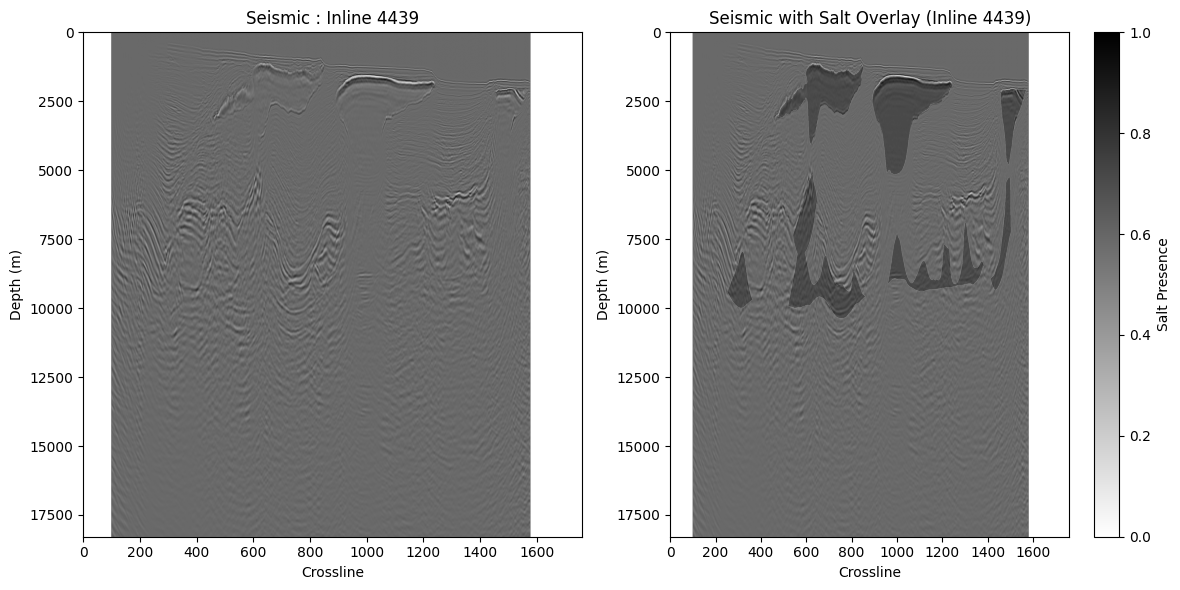

In [13]:
#visualize first inline of seismic and label
#depth is 1876 at 32ft interval, so 1876*32=60032 ft max depth. 
import numpy as np
import matplotlib.pyplot as plt

dz_ft = 32.0
ft_2_m = 0.3048
n_depth = X.shape[2]          # samples along depth
depth_ft = np.arange(n_depth) * dz_ft
depth_m = depth_ft * ft_2_m

# imshow extent: [xmin, xmax, ymin, ymax]
# x: crossline index, y: depth in ft (top=shallow, bottom=deep)
extent = [0, X.shape[1], depth_m[-1], depth_m[0]]

inline_idx = 100  # or whatever inline you want

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(X[inline_idx].T, cmap='gray', aspect='auto',
           extent=extent)
plt.title(f'Seismic : Inline {4039+(4*(inline_idx))}')
plt.xlabel('Crossline')
plt.ylabel('Depth (m)')

#Seismic with salt overlay
plt.subplot(1, 2, 2)
plt.imshow(X[inline_idx].T, cmap='gray', aspect='auto',
           extent=extent)
plt.imshow(y[inline_idx].T, cmap='binary', aspect='auto',
           extent=extent, alpha=(y[inline_idx].T > 0).astype(float) * 0.3)  # Overlay with transparency
plt.title(f'Seismic with Salt Overlay (Inline {4039+(4*(inline_idx))})')
plt.colorbar(label='Salt Presence')
plt.xlabel('Crossline')
plt.ylabel('Depth (m)')

plt.tight_layout()
plt.show()



In [ ]:
#visualize first inline of seismic and label
#depth is 1876 at 32ft interval, so 1876*32=60032 ft max depth. 
import numpy as np
import matplotlib.pyplot as plt

dz_ft = 32.0
ft_2_m = 0.3048
n_depth = X_train.shape[2]          # samples along depth
depth_ft = np.arange(n_depth) * dz_ft
depth_m = depth_ft * ft_2_m

# imshow extent: [xmin, xmax, ymin, ymax]
# x: crossline index, y: depth in ft (top=shallow, bottom=deep)
extent = [0, X_train.shape[1], depth_m[-1], depth_m[0]]

inline_idx = 559  # or whatever inline you want

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(X_train[inline_idx].T, cmap='gray', aspect='auto',
           extent=extent)
plt.title(f'Seismic Inline {4039+(4*(inline_idx))}')
plt.xlabel('Crossline')
plt.ylabel('Depth (m)')

#Seismic with salt overlay
plt.subplot(1, 2, 2)
plt.imshow(X_train[inline_idx].T, cmap='gray', aspect='auto',
           extent=extent)
plt.imshow(y_train[inline_idx].T, cmap='cividis', aspect='auto',
           extent=extent, alpha=(y_train[inline_idx].T > 0).astype(float) * 0.3)  # Overlay with transparency
plt.title(f'Seismic with Salt Overlay (Inline {4039+(4*(inline_idx))})')
plt.colorbar(label='Salt Presence')
plt.xlabel('Crossline')
plt.ylabel('Depth (m)')

plt.tight_layout()
plt.show()



In [ ]:
#visualize first inline of seismic and label
#depth is 1876 at 32ft interval, so 1876*32=60032 ft max depth. 
import numpy as np
import matplotlib.pyplot as plt

dz_ft = 32.0
ft_2_m = 0.3048
n_depth = X_test.shape[2]          # samples along depth
depth_ft = np.arange(n_depth) * dz_ft
depth_m = depth_ft * ft_2_m


# imshow extent: [xmin, xmax, ymin, ymax]
# x: crossline index, y: depth in ft (top=shallow, bottom=deep)
extent = [0, X_test.shape[1], depth_m[-1], depth_m[0]]

inline_idx = 0  # or whatever inline you want

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(X_test[inline_idx].T, cmap='gray', aspect='auto',
           extent=extent)
plt.title(f'Seismic Inline {4039+(4*(inline_idx))}')
plt.xlabel('Crossline')
plt.ylabel('Depth (m)')

#Seismic with salt overlay
plt.subplot(1, 2, 2)
plt.imshow(X_test[inline_idx].T, cmap='gray', aspect='auto',
           extent=extent)
plt.imshow(y_test[inline_idx].T, cmap='cividis', aspect='auto',
           extent=extent, alpha=(y_test[inline_idx].T > 0).astype(float) * 0.5)  # Overlay with transparency
plt.title(f'Seismic with Salt Overlay (Inline {4039+(4*(inline_idx))})')
plt.xlabel('Crossline')
plt.ylabel('Depth (m)')

plt.tight_layout()
plt.show()



In [ ]:
#visualize depth slice of training data
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(X_train[:, :, 500].T, cmap='gray', aspect='auto')
plt.title('Seismic Depth Slice 500')
plt.xlabel('Inline')
plt.ylabel('Crossline')

#seismic with salt overlay
plt.subplot(1, 2, 2)
plt.imshow(X_train[:, :, 500].T, cmap='gray', aspect='auto')
plt.imshow(y_train[:, :, 500].T, cmap='cividis', aspect='auto', alpha=(y_train[:, :, 500].T > 0).astype(float) * 0.5)
plt.title('Seismic with Salt Overlay (Depth Slice 500)')
plt.xlabel('Inline')
plt.ylabel('Crossline')
plt.tight_layout()


In [ ]:
#visualize depth slice of training data
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(X_test[:, :, 500].T, cmap='gray', aspect='auto')
plt.title('Seismic Depth Slice 500')
plt.xlabel('Inline')
plt.ylabel('Crossline')

#seismic with salt overlay
plt.subplot(1, 2, 2)
plt.imshow(X_test[:, :, 500].T, cmap='gray', aspect='auto')
plt.imshow(y_test[:, :, 500].T, cmap='cividis', aspect='auto', alpha=(y_test[:, :, 500].T > 0).astype(float) * 0.5)
plt.title('Seismic with Salt Overlay (Depth Slice 500)')
plt.xlabel('Inline')
plt.ylabel('Crossline')
plt.tight_layout()


### Sampling/Patch Extraction

In [ ]:
import numpy as np
from scipy.ndimage import gaussian_filter

# helper function for data augmentation
#data structure is (inline, crossline, depth)

def random_3d_augmentation(data, mask):
    # 1) Flips
    if np.random.rand() < 0.4:      # inline flip
        data = np.flip(data, axis=0)
        mask = np.flip(mask, axis=0)

    if np.random.rand() < 0.4:      # crossline flip
        data = np.flip(data, axis=1)
        mask = np.flip(mask, axis=1)

    # 2) Rotations in XY plane
    if np.random.rand() < 0.4:
        k = np.random.randint(0, 4)
        data = np.rot90(data, k=k, axes=(0, 1))
        mask = np.rot90(mask, k=k, axes=(0, 1))

    return data, mask


In [ ]:
import numpy as np
import random
import keras
import tensorflow as tf

class DataGenerator(keras.utils.Sequence):
    """NaN-safe 3D seismic patches w/ FG ratio + DEPTH balancing. 
    Pool is generated ONCE at init. Shuffling only affects training.
    """
    
    def __init__(self,
                 data,
                 mask,
                 patch_size=(128, 128, 128),
                 threshold=0.1,
                 max_threshold=0.8,
                 low_fg_max=0.4,
                 low_fg_ratio=0.7,
                 shallow_max_ft=8000,
                 mid_max_ft=25000,
                 batch_size=8,
                 stride=64,
                 max_patches=1000,
                 shuffle=True,
                 augment=False,
                 seed=42,
                 **kwargs):
        super().__init__(**kwargs)
        self.data = data
        self.mask = mask
        self.patch_size = patch_size
        self.threshold = threshold
        self.max_threshold = max_threshold
        self.low_fg_max = low_fg_max
        self.low_fg_ratio = low_fg_ratio
        self.shallow_max_ft = shallow_max_ft
        self.mid_max_ft = mid_max_ft
        self.sample_interval_ft = 32
        self.batch_size = batch_size
        self.stride = stride
        self.max_patches = max_patches
        self.shuffle = shuffle
        self.augment = augment
        self.seed = seed
        
        self._set_seeds()
        self._epoch = 0
        
        # Compute fixed pool of indices ONCE at startup
        self.indices = self._compute_patch_indices()
        
        # Initial shuffle for training
        if self.shuffle:
            np.random.shuffle(self.indices)

    def _set_seeds(self):
        np.random.seed(self.seed)
        random.seed(self.seed)
        tf.random.set_seed(self.seed)

    def _compute_patch_indices(self):
        """Deterministic scan with NaN checking to create fixed pool."""
        print(f"🔧 Computing patches with SEED={self.seed}")
        cl, il, d_samples = self.data.shape
        pcl, pil, pd = self.patch_size
        
        total_depth_ft = d_samples * self.sample_interval_ft
        depth_bins_ft = [(0, self.shallow_max_ft), 
                         (self.shallow_max_ft, self.mid_max_ft), 
                         (self.mid_max_ft, total_depth_ft)]
        
        low_fg_indices = {b: [] for b in range(len(depth_bins_ft))}
        high_fg_indices = {b: [] for b in range(len(depth_bins_ft))}
        
        # 👈 DETERMINISTIC SCAN
        for i in range(0, cl - pcl + 1, self.stride):
            for j in range(0, il - pil + 1, self.stride):
                for k in range(0, d_samples - pd + 1, self.stride):
                    data_patch = self.data[i:i+pcl, j:j+pil, k:k+pd]
                    mask_patch = self.mask[i:i+pcl, j:j+pil, k:k+pd]
                    
                    # 👈 NaN CHECK (Only performed here)
                    if np.isnan(data_patch).any() or np.isnan(mask_patch).any():
                        continue
                    
                    fg_ratio = np.mean(mask_patch)
                    center_ft = (k + pd // 2) * self.sample_interval_ft
                    
                    depth_bin = None
                    for b, (z0, z1) in enumerate(depth_bins_ft):
                        if z0 <= center_ft < z1:
                            depth_bin = b; break
                    
                    if depth_bin is not None:
                        if self.threshold <= fg_ratio <= self.low_fg_max:
                            low_fg_indices[depth_bin].append((i, j, k))
                        elif self.low_fg_max < fg_ratio <= self.max_threshold:
                            high_fg_indices[depth_bin].append((i, j, k))

        total_low = sum(len(v) for v in low_fg_indices.values())
        total_high = sum(len(v) for v in high_fg_indices.values())
        print(f"Found {total_low} LOW FG and {total_high} HIGH FG patches total.")

        bin_weights = [0.33, 0.34, 0.33]
        all_indices = []
        state_before = np.random.get_state()
        np.random.seed(self.seed) 
        
        for b in range(len(depth_bins_ft)):
            bin_low = np.array(low_fg_indices[b])
            bin_high = np.array(high_fg_indices[b])
            n_bin = int(self.max_patches * bin_weights[b])
            n_low = int(self.low_fg_ratio * n_bin)
            n_high = n_bin - n_low
            
            if len(bin_low) > 0:
                idx = np.random.choice(len(bin_low), min(n_low, len(bin_low)), replace=False)
                all_indices.append(bin_low[idx])
            if len(bin_high) > 0:
                idx = np.random.choice(len(bin_high), min(n_high, len(bin_high)), replace=False)
                all_indices.append(bin_high[idx])
        
        result = np.concatenate(all_indices, axis=0)
        np.random.set_state(state_before)
        print(f"✅ Selected {len(result)} total patches (seed={self.seed})")
        return result

    def on_epoch_end(self):
        """Only shuffles the existing pool for training."""
        if self.shuffle:
            self._epoch += 1
            np.random.shuffle(self.indices)

    def __len__(self):
        return int(np.floor(len(self.indices) / self.batch_size))

    def __getitem__(self, index):
        """Pure index lookup for maximum speed."""
        batch_indices = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        
        X = np.zeros((len(batch_indices), *self.patch_size, 1), dtype=np.float32)
        Y = np.zeros((len(batch_indices), *self.patch_size, 1), dtype=np.float32)
        depth_labels = []
        
        for i, (cl_s, il_s, d_s) in enumerate(batch_indices):
            X[i, ..., 0] = self.data[cl_s:cl_s+self.patch_size[0], 
                                     il_s:il_s+self.patch_size[1], 
                                     d_s:d_s+self.patch_size[2]]
            Y[i, ..., 0] = self.mask[cl_s:cl_s+self.patch_size[0], 
                                     il_s:il_s+self.patch_size[1], 
                                     d_s:d_s+self.patch_size[2]]
            
            # Metadata for Depth-Stratified Metrics
            center_ft = (d_s + self.patch_size[2] // 2) * self.sample_interval_ft
            if center_ft < self.shallow_max_ft: label = 0
            elif center_ft < self.mid_max_ft: label = 1
            else: label = 2
            depth_labels.append(label)
            
        return X, Y, depth_labels


In [ ]:
train_gen = DataGenerator(
    X_train,
    y_train,
    patch_size=(128, 128, 128),
    batch_size=2,
    threshold=0.01,
    low_fg_max=0.10,
    max_threshold=0.90,  # Include all FG patches for training
    low_fg_ratio=0.6,  # 25% sediment heavy, 75% salt-heavy
    stride=96,  # Larger stride for fewer, more distinct patches
    max_patches=1500,
    seed=42,
    shuffle=True,
    augment=True,  # Set to False for initial testing; can be True for actual training
    shallow_max_ft=7500,
    mid_max_ft=21000,
)

val_gen = DataGenerator(
    X_test,
    y_test,
    patch_size=(128, 128, 128),
    batch_size=2,
    threshold=0.01,
    low_fg_max=0.10,
    max_threshold=0.30,  # Include all FG patches for validation
    low_fg_ratio=0.25,  # Keep same ratio for validation to reflect training distribution
    stride=96 , # Larger stride for fewer, more distinct patches
    max_patches=200,
    seed=123,  # Different seed for validation to ensure different patch selection
    shuffle=False,  # No shuffling for validation to keep it consistent
    augment=False,
    shallow_max_ft=7500,
    mid_max_ft=21000,
)

### Cost/Loss functions design

In [ ]:
import tensorflow as tf
import tensorflow.keras.backend as K

# ---------- base losses (unchanged idea) ----------
def soft_dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union_sq = K.sum(K.square(y_true_f)) + K.sum(K.square(y_pred_f))
    dice = (2. * intersection + smooth) / (union_sq + smooth)
    return dice

def soft_dice_loss(y_true, y_pred):
    return 1.0 - soft_dice_coef(y_true, y_pred)

def balanced_cross_entropy(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    eps = tf.keras.backend.epsilon()
    y_pred = tf.clip_by_value(y_pred, eps, 1.0 - eps)

    # counts over all voxels (batch-wise)
    count_pos = tf.reduce_sum(y_true)
    count_neg = tf.reduce_sum(1.0 - y_true)

    safe_pos = tf.maximum(count_pos, 1.0)
    safe_neg = tf.maximum(count_neg, 1.0)

    beta = safe_neg / (safe_neg + safe_pos)
    pos_weight = beta / (1.0 - beta + eps)

    logits = tf.math.log(y_pred / (1.0 - y_pred))
    cost = tf.nn.weighted_cross_entropy_with_logits(
        logits=logits, labels=y_true, pos_weight=pos_weight
    )
    cost = tf.reduce_mean(cost * (1.0 - beta))

    # if truly no positives, treat loss as 0 (all-background batch)
    return tf.where(count_pos < eps, 0.0, cost)

# ---------- boundary utilities (fixed) ----------
def get_boundary_mask(y_true, boundary_width=3):
    """
    y_true: (B, X, Y, Z, 1) or (B, X, Y, Z)
    returns: (B, X, Y, Z, 1) boundary mask in {0,1}
    """
    # ensure (B, X, Y, Z, 1)
    if K.ndim(y_true) == 4:
        y = K.expand_dims(y_true, axis=-1)
    else:
        y = y_true

    y_bin = K.cast(y > 0.5, K.floatx())  # (B, X, Y, Z, 1)

    k = 2 * boundary_width + 1
    kernel = tf.ones((k, k, k, 1, 1), dtype=K.floatx())

    # treat (X,Y,Z) as (D,H,W) for conv3d
    dilated = tf.nn.conv3d(
        input=y_bin,
        filters=kernel,
        strides=[1, 1, 1, 1, 1],
        padding='SAME'
    )  # (B, X, Y, Z, 1)

    dilated_bin = K.cast(dilated > 0.5, K.floatx())
    boundary = dilated_bin - y_bin
    boundary = K.clip(boundary, 0.0, 1.0)  # (B, X, Y, Z, 1)

    return boundary

def boundary_dice_loss(y_true, y_pred, boundary_width=3, smooth=1e-6):
    b_true = get_boundary_mask(y_true, boundary_width)   # (B, X, Y, Z, 1)
    b_pred = get_boundary_mask(y_pred, boundary_width)   # (B, X, Y, Z, 1)

    b_true_f = K.flatten(b_true)
    b_pred_f = K.flatten(b_pred)

    inter = K.sum(b_true_f * b_pred_f)
    union = K.sum(K.square(b_true_f)) + K.sum(K.square(b_pred_f))
    bdice = (2. * inter + smooth) / (union + smooth)
    return 1.0 - bdice

def distance_weighted_bce(y_true, y_pred, boundary_width=1):
    """
    BCE up-weighted near ground-truth boundaries.
    Shapes:
      y_true, y_pred: (B, X, Y, Z, 1)
    """
    # boundary mask (B, X, Y, Z, 1)
    b_mask = get_boundary_mask(y_true, boundary_width)   # (B, X, Y, Z, 1)

    # weights same shape as y_true/y_pred
    # e.g., weight=2 at boundary, 1 elsewhere
    weights = 1.0 + b_mask   # (B, X, Y, Z, 1)

    # per-voxel BCE, keepdims True to get (B,X,Y,Z,1)
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    if K.ndim(bce) == 4:
        bce = K.expand_dims(bce, axis=-1)  # (B, X, Y, Z, 1)

    weighted = bce * weights              # broadcast OK now
    return K.mean(weighted)


# ---------- combined salt loss ----------
def salt_ultimate_loss(y_true, y_pred,
                       dice_weight=0.2,
                       bce_weight=0.2,
                       boundary_weight=0.6,
                       boundary_width=3):
    dice = soft_dice_loss(y_true, y_pred)
    bce = balanced_cross_entropy(y_true, y_pred)
    b_dice = boundary_dice_loss(y_true, y_pred, boundary_width)
    b_bce = distance_weighted_bce(y_true, y_pred, boundary_width=boundary_width)

    return (dice_weight * dice +
            bce_weight * bce +
            0.5 * boundary_weight * b_dice +
            0.5 * boundary_weight * b_bce)



# ---------- metrics ----------
def boundary_iou(y_true, y_pred):
    b_true = get_boundary_mask(y_true)
    b_pred = get_boundary_mask(y_pred)
    inter = K.sum(b_true * b_pred)
    union = K.sum(b_true) + K.sum(b_pred) - inter
    return (inter + 1e-6) / (union + 1e-6)

def mean_iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - inter
    return (inter + 1e-6) / (union + 1e-6)


In [ ]:
import keras
import numpy as np
from collections import defaultdict
from scipy.ndimage import binary_dilation

def numpy_boundary_mask(y, boundary_width=2):
    """NumPy implementation of the 3D boundary mask logic."""
    y_bin = (y > 0.5).astype(np.float32)
    k = 2 * boundary_width + 1
    struct = np.ones((k, k, k))
    dilated = binary_dilation(y_bin, structure=struct).astype(np.float32)
    boundary = dilated - y_bin
    return np.clip(boundary, 0.0, 1.0)

def numpy_boundary_iou(y_true, y_pred_bin, boundary_width=2):
    """Calculates Boundary IoU using hard-binarized predictions."""
    b_true = numpy_boundary_mask(y_true, boundary_width)
    b_pred = numpy_boundary_mask(y_pred_bin, boundary_width)
    inter = np.sum(b_true * b_pred)
    union = np.sum(b_true) + np.sum(b_pred) - inter
    return (inter + 1e-6) / (union + 1e-6)

class DepthStratifiedMetrics(keras.callbacks.Callback):
    """
    Callback to monitor Soft Dice (probabilities) and Hard Metrics (binary) 
    across geological depths to identify low-confidence learning.
    """
    def __init__(self, val_gen, boundary_width=2):
        super().__init__()
        self.val_gen = val_gen
        self.boundary_width = boundary_width
        self.dice_history = {'0': [], '1': [], '2': []}
        self.biou_history = {'0': [], '1': [], '2': []}
        
    def on_epoch_end(self, epoch, logs=None):
        print(f"\n🧂 Depth-Stratified Validation (Epoch {epoch+1}):")
        metrics_by_depth = defaultdict(lambda: {'soft_dice': [], 'm_iou': [], 'b_iou': [], 'max_p': []})
        
        for i in range(len(self.val_gen)):
            try:
                X_val, y_true, depth_bins = self.val_gen[i]
                y_pred_raw = self.model.predict(X_val, verbose=0)
                
                # Binary version for IoU and Commitment tracking
                y_pred_bin = (y_pred_raw > 0.5).astype(np.float32)
                
                for j in range(len(X_val)):
                    depth = str(depth_bins[j])
                    yt = np.squeeze(y_true[j])
                    yp_soft = np.squeeze(y_pred_raw[j])
                    yp_bin = np.squeeze(y_pred_bin[j])
                    
                    # 1. SOFT DICE (Raw probabilities vs True Mask)
                    s_dice = self._loss_equivalent_dice(yt, yp_soft)
                    
                    # 2. Hard Metrics (Binarized)
                    m_iou = self._loss_equivalent_iou(yt, yp_bin)
                    b_iou = numpy_boundary_iou(yt, yp_bin, self.boundary_width)
                    
                    metrics_by_depth[depth]['soft_dice'].append(s_dice)
                    metrics_by_depth[depth]['m_iou'].append(m_iou)
                    metrics_by_depth[depth]['b_iou'].append(b_iou)
                    metrics_by_depth[depth]['max_p'].append(np.max(yp_soft))
                    
            except Exception as e:
                print(f"Skipped batch {i}: {e}")
                continue
        
        self._store_history(metrics_by_depth)
        self._print_results(metrics_by_depth)

    def _loss_equivalent_dice(self, y_true, y_pred):
        """Soft Dice calculation using raw probabilities and Square Union."""
        inter = np.sum(y_true * y_pred)
        union_sq = np.sum(np.square(y_true)) + np.sum(np.square(y_pred))
        return (2. * inter + 1e-6) / (union_sq + 1e-6)

    def _loss_equivalent_iou(self, y_true, y_pred):
        """Hard IoU calculation."""
        inter = np.sum(y_true * y_pred)
        union = np.sum(y_true) + np.sum(y_pred) - inter
        return (inter + 1e-6) / (union + 1e-6)

    def _store_history(self, metrics_by_depth):
        for d_str in ['0', '1', '2']:
            if d_str in metrics_by_depth:
                d = metrics_by_depth[d_str]
                self.dice_history[d_str].append(np.mean(d['soft_dice']))
                self.biou_history[d_str].append(np.mean(d['b_iou']))

    def _print_results(self, metrics_by_depth):
        all_dice, all_biou = [], []
        for d in metrics_by_depth.values():
            all_dice.extend(d['soft_dice'])
            all_biou.extend(d['b_iou'])
        
        if not all_dice: return
        print(f"Overall Avg | SoftDice: {np.mean(all_dice):.4f} | bIoU: {np.mean(all_biou):.4f}")
        
        for depth in sorted(metrics_by_depth.keys()):
            d = metrics_by_depth[depth]
            n = len(d['soft_dice'])
            avg_max = np.mean(d['max_p'])
            print(f"    Depth {depth} | SoftDice: {np.mean(d['soft_dice']):.4f}±{np.std(d['soft_dice']):.3f} | "
                  f"bIoU: {np.mean(d['b_iou']):.4f} | MaxP: {avg_max:.2f} ({n} patches)")


### Model Architecture Design

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers as L
from tensorflow.keras.optimizers import Adam

# Use BatchNormalization for small batch stability at 192^3
def conv_bn_relu_3d(x, filters, kernel_size=3, strides=1, l2_reg=1e-4):
    x = L.Conv3D(filters, kernel_size, strides=strides, padding='same', use_bias=False,
                 kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    # Fallback to BN if GN is missing
    x = L.BatchNormalization(momentum=0.9)(x) 
    x = L.Activation('relu')(x)
    return x


def residual_bottleneck_lite_3d(x, filters, strides=1, l2_reg=1e-4):
    shortcut = x
    expansion = 2 
    out_filters = filters * expansion

    x = conv_bn_relu_3d(x, filters, kernel_size=1, strides=strides, l2_reg=l2_reg)
    x = conv_bn_relu_3d(x, filters, kernel_size=3, strides=1, l2_reg=l2_reg)
    x = L.Conv3D(out_filters, 1, strides=1, padding='same', use_bias=False,
                 kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = L.BatchNormalization(momentum=0.9)(x) # Use BN as fallback

    if shortcut.shape[-1] != out_filters or strides != 1:
        shortcut = L.Conv3D(out_filters, 1, strides=strides, padding='same', use_bias=False,
                            kernel_initializer='he_normal', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(shortcut)
        shortcut = L.BatchNormalization(momentum=0.9)(shortcut)

    x = L.Add()([x, shortcut])
    x = L.Activation('relu')(x)
    return x

def make_lite_layer_3d(x, filters, blocks, strides=1, l2_reg=1e-4):
    x = residual_bottleneck_lite_3d(x, filters, strides=strides, l2_reg=l2_reg)
    for _ in range(1, blocks):
        x = residual_bottleneck_lite_3d(x, filters, strides=1, l2_reg=l2_reg)
    return x

def symmetrical_resnet50_lite_192(input_shape=(192, 192, 192, 1), l2_reg=1e-4, lr=1e-4,loss = None):
    inputs = L.Input(shape=input_shape)
    
    # ENCODER - Downscaled filter counts to fit 192^3
    e0_pre = conv_bn_relu_3d(inputs, 16, kernel_size=7, strides=1) 
    e0 = L.MaxPooling3D(pool_size=2)(e0_pre) # 96^3

    e1 = make_lite_layer_3d(e0, 16, blocks=1) # 96^3, 32 filters
    e2 = make_lite_layer_3d(e1, 32, blocks=1, strides=2) # 48^3, 64 filters
    e3 = make_lite_layer_3d(e2, 64, blocks=1, strides=2) # 24^3, 128 filters
    e4 = make_lite_layer_3d(e3, 128, blocks=1, strides=2) # 12 = 12^3, 256 filters

    # BRIDGE
    b = make_lite_layer_3d(e4, 128, blocks=1)

    # DECODER - UpSampling3D is lighter than Conv3DTranspose
    def decoder_block(x, skip, filters, blocks):
        x = L.UpSampling3D(size=(2,2,2))(x)
        x = L.Concatenate()([x, skip])
        return make_lite_layer_3d(x, filters, blocks=blocks)

    d1 = decoder_block(b, e3, 64, blocks=3)  # 24^3
    d2 = decoder_block(d1, e2, 32, blocks=2) # 48^3
    d3 = decoder_block(d2, e1, 16, blocks=1) # 96^3
    
    # Final Stage to 192^3
    d4 = L.UpSampling3D(size=(2,2,2))(d3)
    d4 = L.Concatenate()([d4, e0_pre])
    
    x = conv_bn_relu_3d(d4, 16, kernel_size=3)
    output = L.Conv3D(1, 1, padding='same', activation='sigmoid')(x)

    model = tf.keras.Model(inputs, output)
    model.compile(optimizer=Adam(learning_rate=lr), 
                  loss=loss,
                  metrics=[soft_dice_coef, mean_iou, boundary_iou, distance_weighted_bce, boundary_dice_loss])
    return model



In [ ]:
base_model = symmetrical_resnet50_lite_192(input_shape=(192, 192, 192, 1),loss=salt_ultimate_loss, lr=5e-5)


In [ ]:
base_model.summary()

In [ ]:
# # Callback for base model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

base_callbacks = [
    # 1. Early Stopping: Keep on val_loss to prevent overall divergence
    EarlyStopping(
        monitor='val_loss', 
        mode='min', 
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    
    # 2. ReduceLR: Monitor the actual accuracy metric (Dice)
    # This ensures we only slow down when the salt shapes stop improving
    ReduceLROnPlateau(
        monitor='val_soft_dice_coef', 
        mode='max', # Dice should go UP
        factor=0.5,
        patience=8, # Slightly more aggressive than EarlyStopping
        min_lr=1e-7,
        verbose=1
    ),

    # 3. Checkpoint: Save based on the best Dice score
    # This is usually the model that looks best to human eyes
    ModelCheckpoint(
        'base_model_best.h5', 
        monitor='val_soft_dice_coef', 
        save_best_only=True,
        mode='max', # Dice should go UP
        verbose=1
    ),
    
    # 4. Your Custom Depth Metric (for analysis, not for stopping)
    DepthStratifiedMetrics(val_gen=val_gen, boundary_width=2)
]


In [ ]:

# Cell 1: Base model ONLY
base_history = base_model.fit(train_gen, validation_data=val_gen, epochs=75, callbacks=base_callbacks)
base_model.save_weights('base_model_best.h5')



In [ ]:
# saving the base model

base_model.save('models/resnet50_base_model_final.h5')

In [ ]:
# 3. Plot curves for THREE HEADLINE METRICS (Dice + IoU + Boundary IoU)
fig, (ax1, ax2, ax3,ax4) = plt.subplots(1, 4, figsize=(24, 5), dpi=300)
fig.suptitle("GoM Salt Segmentation: Headline Metrics", fontsize=14, fontweight='bold')

# 1. Soft Dice (Primary volumetric)
best_epoch_dice = np.argmax(base_history.history['val_soft_dice_coef'])
best_val_dice = base_history.history['val_soft_dice_coef'][best_epoch_dice]
ax1.plot(base_history.history['soft_dice_coef'], label='Train', color='#1f77b4', lw=2.5)
ax1.plot(base_history.history['val_soft_dice_coef'], label='Val', color='#d62728', lw=2.5)
ax1.scatter(best_epoch_dice, best_val_dice, color='#2ca02c', zorder=5, s=60)
ax1.text(best_epoch_dice+0.5, best_val_dice, f'{best_val_dice:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax1.set_ylabel('Soft Dice')
ax1.set_xlabel('Epoch')
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)
ax1.set_title('Dice Coefficient', fontweight='bold')

# 2. Mean IoU (Secondary volumetric)  
best_epoch_iou = np.argmax(base_history.history['val_mean_iou'])
best_val_iou = base_history.history['val_mean_iou'][best_epoch_iou]
ax2.plot(base_history.history['mean_iou'], label='Train', color='#ff7f0e', lw=2.5)
ax2.plot(base_history.history['val_mean_iou'], label='Val', color='#ff7f0e', lw=2.5, alpha=0.8)
ax2.scatter(best_epoch_iou, best_val_iou, color='#ff7f0e', zorder=5, s=60)
ax2.text(best_epoch_iou+0.5, best_val_iou, f'{best_val_iou:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax2.set_ylabel('Mean IoU')
ax2.set_xlabel('Epoch')
ax2.legend(frameon=False)
ax2.grid(True, alpha=0.3)
ax2.set_title('Mean IoU', fontweight='bold')

# 3. Boundary IoU (Boundary quality - YOUR KEY METRIC)
best_epoch_biou = np.argmax(base_history.history['val_boundary_iou'])
best_val_biou = base_history.history['val_boundary_iou'][best_epoch_biou]
ax3.plot(base_history.history['boundary_iou'], label='Train', color='#9467bd', lw=2.5)
ax3.plot(base_history.history['val_boundary_iou'], label='Val', color='#9467bd', lw=2.5, alpha=0.8)
ax3.scatter(best_epoch_biou, best_val_biou, color='#9467bd', zorder=5, s=60)
ax3.text(best_epoch_biou+0.5, best_val_biou, f'{best_val_biou:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax3.set_ylabel('Boundary IoU')
ax3.set_xlabel('Epoch')
ax3.legend(frameon=False)
ax3.grid(True, alpha=0.3)
ax3.set_title('Boundary IoU', fontweight='bold')

#4. Loss Curve (Optional, can be added as a 4th subplot if desired)
ax4 = plt.subplot(1, 4, 4)
ax4.plot(base_history.history['loss'], label='Train', color='#1f77b4', lw=2.5)
ax4.plot(base_history.history['val_loss'], label='Val', color='#d62728', lw=2.5)
ax4.set_ylabel('Loss')
ax4.set_xlabel('Epoch')
ax4.legend(frameon=False)
ax4.grid(True, alpha=0.3)
ax4.set_title('Loss', fontweight='bold')


plt.tight_layout()
plt.savefig('gom_headline_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: gom_headline_metrics.png")
plt.show()
plt.close()


### Depth Metrics Visualization

In [ ]:
# ========== PLOTTING FUNCTION (run after training) ==========
def plot_depth_metrics(callback):
    """Plot depth-stratified metrics from callback history."""
    epochs = range(1, len(callback.dice_history['0']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Dice plot
    ax1.plot(epochs, callback.dice_history['0'], 'o-', label='Shallow (D0)', linewidth=2, markersize=6)
    ax1.plot(epochs, callback.dice_history['1'], 's-', label='Mid (D1)', linewidth=2, markersize=6)
    ax1.plot(epochs, callback.dice_history['2'], '^-', label='Deep (D2)', linewidth=2, markersize=6)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Dice')
    ax1.set_title('Depth-Stratified Dice Evolution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # bIoU plot
    ax2.plot(epochs, callback.biou_history['0'], 'o-', label='Shallow (D0)', linewidth=2, markersize=6)
    ax2.plot(epochs, callback.biou_history['1'], 's-', label='Mid (D1)', linewidth=2, markersize=6)
    ax2.plot(epochs, callback.biou_history['2'], '^-', label='Deep (D2)', linewidth=2, markersize=6)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Boundary IoU (bIoU)')
    ax2.set_title('Depth-Stratified bIoU Evolution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('depth_metrics_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Depth metrics plotted and saved as 'depth_metrics_evolution.png'")
    return fig

In [ ]:
plot_depth_metrics(base_callbacks[-1])  # Pass the DepthStratifiedMetrics callback instance

### Seismic Pertubed model using transfer learning from base_model

In [ ]:
def seismic_perturbation_gen(data_gen, perturbation_prob=0.5): # Boosted default prob
    """
    AGGRESSIVE GPU-accelerated augmentation - D0/SHALLOW ONLY.
    Simulates 'Deep' complexity on 'Shallow' patches.
    """
    while True:
        for batch_data, batch_mask, depth_labels in data_gen:
            orig_data = tf.convert_to_tensor(batch_data, dtype=tf.float32)
            batch_size = tf.shape(orig_data)[0]
            depth_labels_tf = tf.convert_to_tensor(depth_labels)

            if len(depth_labels_tf.shape) > 1:
                depth_labels_tf = tf.squeeze(depth_labels_tf, axis=-1)

            # D0 and Perturbation masks
            is_d0 = tf.equal(depth_labels_tf, 0)
            perturb_mask = tf.random.uniform([batch_size, 1, 1, 1, 1]) < perturbation_prob
            is_d0_5d = is_d0[:, tf.newaxis, tf.newaxis, tf.newaxis, tf.newaxis]
            final_mask = tf.logical_and(is_d0_5d, perturb_mask)

            aug_data = orig_data

            # 1. AGGRESSIVE GAIN & ATTENUATION (0.2x to 2.0x)
            # Simulates signal "washout" common in deep geology
            gains = tf.random.uniform([batch_size, 1, 1, 1, 1], 0.2, 2.0)
            aug_data = aug_data * gains

            # 2. SEVERE COHERENT NOISE (Simulating seismic "chatter")
            # Uses higher noise floor (up to 40% of data std)
            data_std = tf.math.reduce_std(aug_data)
            noise_std = tf.random.uniform([batch_size], 0.15, 0.40) * data_std
            noise = tf.random.normal(
                tf.shape(aug_data), 0.0, 
                noise_std[:, tf.newaxis, tf.newaxis, tf.newaxis, tf.newaxis]
            )
            aug_data = aug_data + noise

            # 3. MIGRATION "SMILE" & DIFFRACTION ARTIFACTS
            # Increased strength and randomized frequencies to distort boundaries
            smile_strength = tf.random.uniform([batch_size, 1, 1, 1, 1], 0.05, 0.15)
            time_dim = tf.shape(aug_data)[1]
            # Randomize frequency of the smile (1 to 4 cycles)
            freq = tf.random.uniform([], 1.0, 4.0) * np.pi
            t = tf.linspace(0.0, freq, time_dim)
            phases = tf.random.uniform([batch_size], 0.0, 2 * np.pi)
            
            wave = smile_strength * tf.sin(
                t[tf.newaxis, :, tf.newaxis, tf.newaxis, tf.newaxis] +
                phases[:, tf.newaxis, tf.newaxis, tf.newaxis, tf.newaxis]
            )
            aug_data = aug_data + wave

            # 4. SPECTRAL WHITENING / BLUR (Simulating low-frequency deep data)
            # Simple 3D Average pooling + upsampling to "blur" the features
            blur_kernel = tf.ones((3, 3, 3, 1, 1)) / 27.0
            blurred = tf.nn.conv3d(aug_data, blur_kernel, strides=[1,1,1,1,1], padding='SAME')
            # Mix original and blurred based on a 50/50 chance per sample
            do_blur = tf.random.uniform([batch_size, 1, 1, 1, 1]) < 0.5
            aug_data = tf.where(do_blur, blurred, aug_data)

            # 5. HEAVY CLIPPING
            # Forcing the model to learn from "saturated" or "weak" amplitudes
            X_STD = 1.0
            aug_data = tf.clip_by_value(aug_data, -1.5 * X_STD, 1.5 * X_STD)

            final_batch = tf.where(final_mask, aug_data, orig_data)
            yield final_batch.numpy(), batch_mask, depth_labels

        data_gen.on_epoch_end()


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Make sure these names ('soft_dice_coef', 'boundary_iou') match 
# exactly what you pass to model.compile(metrics=[...])
seismic_callbacks = [
    # 🥇 BOUNDARY PRIMARY CHECKPOINT (Fixed monitor name)
    # Critical for sharp velocity models in seismic inversion
    ModelCheckpoint(
        'seismic_model_best_boundary.h5', 
        monitor='val_boundary_iou',     # 👈 Matches the metric function name
        save_best_only=True,
        mode='max',                     # Higher IoU is better
        verbose=1
    ),
    
    # 🥈 DICE PRIMARY CHECKPOINT (Overall volume quality)
    ModelCheckpoint(
        'seismic_model_best_dice.h5', 
        monitor='val_soft_dice_coef',   # 👈 Matches the metric function name
        save_best_only=True,
        mode='max', 
        verbose=1
    ),
    
    # 🛑 Early stopping on Dice
    # Using Dice instead of loss avoids stopping due to noisy BCE spikes
    EarlyStopping(
        monitor='val_soft_dice_coef',
        mode='max', 
        patience=25,                    # Give it more room to breathe
        restore_best_weights=True,
        verbose=1
    ),
    
    # 📉 LR reduction on Dice plateau
    ReduceLROnPlateau(
        monitor='val_soft_dice_coef',
        mode='max',
        factor=0.5,
        patience=10,                    # Drop LR after 10 epochs of no Dice improvement
        min_lr=1e-7,
        verbose=1
    ),
    
    # 📊 Your custom depth-stratified analysis
    # Ensure boundary_width matches your loss function (default=2)
    DepthStratifiedMetrics(val_gen=val_gen, boundary_width=2)
]


In [ ]:
seismic_model = symmetrical_resnet50_lite_192(input_shape=(192, 192, 192, 1),loss=salt_ultimate_loss, lr=5e-5) 
seismic_model.load_weights('base_model_best.h5')  # Load base model weights



In [ ]:
# Cell 2: Seismic model ONLY  
seismic_history = seismic_model.fit(seismic_perturbation_gen(train_gen,perturbation_prob=0.75), validation_data=val_gen, epochs=75, callbacks=seismic_callbacks,steps_per_epoch=140)  # steps_per_epoch to control how many batches per epoch   
seismic_model.save_weights('seismic_model_best.h5')


In [ ]:
# saving the seismic model

seismic_model.save('models/seismic_model_final.h5')

In [ ]:
# 3. Plot curves for THREE HEADLINE METRICS (Dice + IoU + Boundary IoU)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=300)
fig.suptitle("GoM Salt Segmentation: Headline Metrics", fontsize=14, fontweight='bold')

# 1. Soft Dice (Primary volumetric)
best_epoch_dice = np.argmax(seismic_history.history['val_soft_dice_coef'])
best_val_dice = seismic_history.history['val_soft_dice_coef'][best_epoch_dice]
ax1.plot(seismic_history.history['soft_dice_coef'], label='Train', color='#1f77b4', lw=2.5)
ax1.plot(seismic_history.history['val_soft_dice_coef'], label='Val', color='#d62728', lw=2.5)
ax1.scatter(best_epoch_dice, best_val_dice, color='#2ca02c', zorder=5, s=60)
ax1.text(best_epoch_dice+0.5, best_val_dice, f'{best_val_dice:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax1.set_ylabel('Soft Dice')
ax1.set_xlabel('Epoch')
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)
ax1.set_title('Dice Coefficient', fontweight='bold')

# 2. Mean IoU (Secondary volumetric)  
best_epoch_iou = np.argmax(seismic_history.history['val_mean_iou'])
best_val_iou = seismic_history.history['val_mean_iou'][best_epoch_iou]
ax2.plot(seismic_history.history['mean_iou'], label='Train', color='#ff7f0e', lw=2.5)
ax2.plot(seismic_history.history['val_mean_iou'], label='Val', color='#ff7f0e', lw=2.5, alpha=0.8)
ax2.scatter(best_epoch_iou, best_val_iou, color='#ff7f0e', zorder=5, s=60)
ax2.text(best_epoch_iou+0.5, best_val_iou, f'{best_val_iou:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax2.set_ylabel('Mean IoU')
ax2.set_xlabel('Epoch')
ax2.legend(frameon=False)
ax2.grid(True, alpha=0.3)
ax2.set_title('Mean IoU', fontweight='bold')

# 3. Boundary IoU (Boundary quality - YOUR KEY METRIC)
best_epoch_biou = np.argmax(seismic_history.history['val_boundary_iou'])
best_val_biou = seismic_history.history['val_boundary_iou'][best_epoch_biou]
ax3.plot(seismic_history.history['boundary_iou'], label='Train', color='#9467bd', lw=2.5)
ax3.plot(seismic_history.history['val_boundary_iou'], label='Val', color='#9467bd', lw=2.5, alpha=0.8)
ax3.scatter(best_epoch_biou, best_val_biou, color='#9467bd', zorder=5, s=60)
ax3.text(best_epoch_biou+0.5, best_val_biou, f'{best_val_biou:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax3.set_ylabel('Boundary IoU')
ax3.set_xlabel('Epoch')
ax3.legend(frameon=False)
ax3.grid(True, alpha=0.3)
ax3.set_title('Boundary IoU', fontweight='bold')

plt.tight_layout()
plt.savefig('gom_headline_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: gom_headline_metrics.png")
plt.show()
plt.close()


In [ ]:
# ========== PLOTTING FUNCTION (run after training) ==========
def plot_depth_metrics(callback):
    """Plot depth-stratified metrics from callback history."""
    epochs = range(1, len(callback.dice_history['0']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Dice plot
    ax1.plot(epochs, callback.dice_history['0'], 'o-', label='Shallow (D0)', linewidth=2, markersize=6)
    ax1.plot(epochs, callback.dice_history['1'], 's-', label='Mid (D1)', linewidth=2, markersize=6)
    ax1.plot(epochs, callback.dice_history['2'], '^-', label='Deep (D2)', linewidth=2, markersize=6)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Dice')
    ax1.set_title('Depth-Stratified Dice Evolution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # bIoU plot
    ax2.plot(epochs, callback.biou_history['0'], 'o-', label='Shallow (D0)', linewidth=2, markersize=6)
    ax2.plot(epochs, callback.biou_history['1'], 's-', label='Mid (D1)', linewidth=2, markersize=6)
    ax2.plot(epochs, callback.biou_history['2'], '^-', label='Deep (D2)', linewidth=2, markersize=6)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Boundary IoU (bIoU)')
    ax2.set_title('Depth-Stratified bIoU Evolution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('depth_metrics_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Depth metrics plotted and saved as 'depth_metrics_evolution.png'")
    return fig

In [ ]:
plot_depth_metrics(seismic_callbacks[-1])  # plotting seismic model's depth metrics

### Label Perturbed model using transfer learning from base model

In [ ]:
from scipy.ndimage import gaussian_filter, binary_erosion, binary_dilation
import numpy as np

def label_perturbation_gen(data_gen, perturbation_prob=0.4):
    while True:
        for batch_data, batch_mask, depth_labels in data_gen:
            # Create a clean copy so we don't modify the original validation/train set
            batch_mask_perturbed = batch_mask.copy().astype(np.float32)
            
            for i in range(batch_mask_perturbed.shape[0]):
                if np.random.rand() < perturbation_prob:
                    # Select the slice. Supports (B, X, Y, Z, 1) or (B, X, Y, Z)
                    has_channel = batch_mask_perturbed.ndim == 5
                    mask_slice = batch_mask_perturbed[i, ..., 0] if has_channel else batch_mask_perturbed[i]
                    
                    # 1. Gaussian boundary blur (Simulates seismic uncertainty)
                    sigma = np.random.uniform(1.0, 2.0)
                    mask_slice = gaussian_filter(mask_slice, sigma=sigma)
                    
                    # 2. Salt fraction jitter (Simulates interpreter bias)
                    if np.random.rand() < 0.3:
                        current_frac = np.mean(mask_slice)
                        if 0.01 < current_frac < 0.99:
                            binary_mask = mask_slice > 0.5
                            
                            # Randomly grow or shrink the salt body
                            if np.random.rand() > 0.5:
                                processed = binary_erosion(binary_mask, iterations=1)
                            else:
                                processed = binary_dilation(binary_mask, iterations=1)
                            
                            mask_slice = gaussian_filter(processed.astype(np.float32), sigma=0.5)
                    
                    # Put the modified slice back
                    if has_channel:
                        batch_mask_perturbed[i, ..., 0] = np.clip(mask_slice, 0, 1)
                    else:
                        batch_mask_perturbed[i] = np.clip(mask_slice, 0, 1)
            
            yield batch_data, batch_mask_perturbed, depth_labels
        
        # Trigger reshuffle if the underlying generator has it
        if hasattr(data_gen, 'on_epoch_end'):
            data_gen.on_epoch_end()


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Make sure these monitor names match your model.compile(metrics=[...]) exactly
label_callbacks = [
    # 🥇 BOUNDARY PRIMARY CHECKPOINT 
    # Best for sharp salt-sediment interfaces (critical for velocity models)
    ModelCheckpoint(
        'label_model_best_boundary.h5', 
        monitor='val_boundary_iou',      # 👈 Ensure this matches your metric name
        save_best_only=True,
        mode='max',                      # Higher is better
        verbose=1
    ),
    
    # 🥈 DICE PRIMARY CHECKPOINT 
    # Best for overall salt volume and connectivity
    ModelCheckpoint(
        'label_model_best_dice.h5', 
        monitor='val_soft_dice_coef',    # 👈 Ensure this matches your metric name
        save_best_only=True,
        mode='max', 
        verbose=1
    ),
    
    # 🛑 Early stopping on Dice
    # Using Dice instead of Loss prevents stopping due to minor BCE fluctuations
    EarlyStopping(
        monitor='val_soft_dice_coef', 
        mode='max', 
        patience=20,                     # Stop training after 20 epochs of no improvement
        restore_best_weights=True,
        verbose=1
    ),
    
    # 📉 Learning Rate Reduction
    # Slower learning when the salt shapes stop improving
    ReduceLROnPlateau(
        monitor='val_soft_dice_coef',
        mode='max',
        factor=0.5,
        patience=10,                     # Reduce LR after 10 epochs of plateau
        min_lr=1e-7,
        verbose=1
    ),
    
    # 📊 Custom Analysis Callback
    # Match the boundary_width (2) used in your "Ultimate Loss"
    DepthStratifiedMetrics(val_gen=val_gen, boundary_width=2)
]


In [ ]:
label_model = symmetrical_resnet50_lite_192(input_shape=(192, 192, 192, 1),loss=salt_ultimate_loss, lr=5e-5) 
label_model.load_weights('base_model_best.h5')  # Load base model weights



In [ ]:
# Cell 2: Seismic model ONLY  
label_history = label_model.fit(label_perturbation_gen(train_gen,perturbation_prob=0.35), validation_data=val_gen, epochs=75, callbacks=label_callbacks,steps_per_epoch=140)  # steps_per_epoch to control how many batches per epoch   
label_model.save_weights('label_model_best.h5')
    

In [ ]:
# saving the label model

label_model.save('models/label_model_final.h5')

In [ ]:
# 3. Plot curves for THREE HEADLINE METRICS (Dice + IoU + Boundary IoU)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=300)
fig.suptitle("GoM Salt Segmentation: Headline Metrics", fontsize=14, fontweight='bold')

# 1. Soft Dice (Primary volumetric)
best_epoch_dice = np.argmax(label_history.history['val_soft_dice_coef'])
best_val_dice = label_history.history['val_soft_dice_coef'][best_epoch_dice]
ax1.plot(label_history.history['soft_dice_coef'], label='Train', color='#1f77b4', lw=2.5)
ax1.plot(label_history.history['val_soft_dice_coef'], label='Val', color='#d62728', lw=2.5)
ax1.scatter(best_epoch_dice, best_val_dice, color='#2ca02c', zorder=5, s=60)
ax1.text(best_epoch_dice+0.5, best_val_dice, f'{best_val_dice:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax1.set_ylabel('Soft Dice')
ax1.set_xlabel('Epoch')
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)
ax1.set_title('Dice Coefficient', fontweight='bold')

# 2. Mean IoU (Secondary volumetric)  
best_epoch_iou = np.argmax(label_history.history['val_mean_iou'])
best_val_iou = label_history.history['val_mean_iou'][best_epoch_iou]
ax2.plot(label_history.history['mean_iou'], label='Train', color='#ff7f0e', lw=2.5)
ax2.plot(label_history.history['val_mean_iou'], label='Val', color='#ff7f0e', lw=2.5, alpha=0.8)
ax2.scatter(best_epoch_iou, best_val_iou, color='#ff7f0e', zorder=5, s=60)
ax2.text(best_epoch_iou+0.5, best_val_iou, f'{best_val_iou:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax2.set_ylabel('Mean IoU')
ax2.set_xlabel('Epoch')
ax2.legend(frameon=False)
ax2.grid(True, alpha=0.3)
ax2.set_title('Mean IoU', fontweight='bold')

# 3. Boundary IoU (Boundary quality - YOUR KEY METRIC)
best_epoch_biou = np.argmax(label_history.history['val_boundary_iou'])
best_val_biou = label_history.history['val_boundary_iou'][best_epoch_biou]
ax3.plot(label_history.history['boundary_iou'], label='Train', color='#9467bd', lw=2.5)
ax3.plot(label_history.history['val_boundary_iou'], label='Val', color='#9467bd', lw=2.5, alpha=0.8)
ax3.scatter(best_epoch_biou, best_val_biou, color='#9467bd', zorder=5, s=60)
ax3.text(best_epoch_biou+0.5, best_val_biou, f'{best_val_biou:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax3.set_ylabel('Boundary IoU')
ax3.set_xlabel('Epoch')
ax3.legend(frameon=False)
ax3.grid(True, alpha=0.3)
ax3.set_title('Boundary IoU', fontweight='bold')

plt.tight_layout()
plt.savefig('gom_headline_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: gom_headline_metrics.png")
plt.show()
plt.close()


In [ ]:
# ========== PLOTTING FUNCTION (run after training) ==========
def plot_depth_metrics(callback):
    """Plot depth-stratified metrics from callback history."""
    epochs = range(1, len(callback.dice_history['0']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Dice plot
    ax1.plot(epochs, callback.dice_history['0'], 'o-', label='Shallow (D0)', linewidth=2, markersize=6)
    ax1.plot(epochs, callback.dice_history['1'], 's-', label='Mid (D1)', linewidth=2, markersize=6)
    ax1.plot(epochs, callback.dice_history['2'], '^-', label='Deep (D2)', linewidth=2, markersize=6)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Dice')
    ax1.set_title('Depth-Stratified Dice Evolution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # bIoU plot
    ax2.plot(epochs, callback.biou_history['0'], 'o-', label='Shallow (D0)', linewidth=2, markersize=6)
    ax2.plot(epochs, callback.biou_history['1'], 's-', label='Mid (D1)', linewidth=2, markersize=6)
    ax2.plot(epochs, callback.biou_history['2'], '^-', label='Deep (D2)', linewidth=2, markersize=6)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Boundary IoU (bIoU)')
    ax2.set_title('Depth-Stratified bIoU Evolution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('depth_metrics_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Depth metrics plotted and saved as 'depth_metrics_evolution.png'")
    return fig

In [ ]:
plot_depth_metrics(label_callbacks[-1])  # plotting label model's depth metrics

### Seismic + Label Perturbation

In [ ]:
seismic_label_model = symmetrical_resnet50_lite_192(input_shape=(192, 192, 192, 1),loss=salt_ultimate_loss, lr=5e-5)
seismic_label_model.load_weights('base_model_best.h5')  # Load base model weights

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Finalized Seismic-Label callbacks
seismic_label_callbacks = [
    # 🥇 BOUNDARY PRIMARY CHECKPOINT 
    # Best for velocity models where salt-sediment interface precision is key
    ModelCheckpoint(
        'seismic_label_model_best_boundary.h5', 
        monitor='val_boundary_iou',      # 👈 Monitor for best boundary overlap
        save_best_only=True,
        mode='max',                      
        verbose=1
    ),
    
    # 🥈 DICE PRIMARY CHECKPOINT 
    # Best for overall salt volume and spatial consistency
    ModelCheckpoint(
        'seismic_label_model_best_dice.h5', 
        monitor='val_soft_dice_coef',    # 👈 Monitor for best overall overlap
        save_best_only=True,
        mode='max', 
        verbose=1
    ),
    
    # 🛑 Early stopping on Dice
    # Prevents overfitting once the main shape stops improving
    EarlyStopping(
        monitor='val_soft_dice_coef',
        mode='max', 
        patience=20,                     # Stop after 20 epochs of no improvement
        restore_best_weights=True,
        verbose=1
    ),
    
    # 📉 LR reduction on Dice plateau
    ReduceLROnPlateau(
        monitor='val_soft_dice_coef',
        mode='max',
        factor=0.5,
        patience=10,                    # Drop LR after 10 epochs of plateau
        min_lr=1e-7,
        verbose=1
    ),
    
    # 📊 Custom Depth-Stratified Analysis
    # Ensure boundary_width matches the '2' used in your salt_ultimate_loss
    DepthStratifiedMetrics(val_gen=val_gen, boundary_width=2)
]


In [ ]:

seismic_label_history = seismic_label_model.fit(seismic_perturbation_gen(label_perturbation_gen(train_gen, perturbation_prob=0.3), perturbation_prob=0.5), validation_data=val_gen, epochs=75, callbacks=seismic_label_callbacks, steps_per_epoch=73)  # Nested perturbation for stronger augmentation
seismic_label_model.save_weights('seismic_label_model_best.h5')

In [ ]:
# saving the label model

label_model.save('models/seismic_label_model_final.h5')

In [ ]:
# 3. Plot curves for THREE HEADLINE METRICS (Dice + IoU + Boundary IoU)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5), dpi=300)
fig.suptitle("GoM Salt Segmentation: Headline Metrics", fontsize=14, fontweight='bold')

# 1. Soft Dice (Primary volumetric)
best_epoch_dice = np.argmax(seismic_label_history.history['val_soft_dice_coef'])
best_val_dice = seismic_label_history.history['val_soft_dice_coef'][best_epoch_dice]
ax1.plot(seismic_label_history.history['soft_dice_coef'], label='Train', color='#1f77b4', lw=2.5)
ax1.plot(seismic_label_history.history['val_soft_dice_coef'], label='Val', color='#d62728', lw=2.5)
ax1.scatter(best_epoch_dice, best_val_dice, color='#2ca02c', zorder=5, s=60)
ax1.text(best_epoch_dice+0.5, best_val_dice, f'{best_val_dice:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax1.set_ylabel('Soft Dice')
ax1.set_xlabel('Epoch')
ax1.legend(frameon=False)
ax1.grid(True, alpha=0.3)
ax1.set_title('Dice Coefficient', fontweight='bold')

# 2. Mean IoU (Secondary volumetric)  
best_epoch_iou = np.argmax(seismic_label_history.history['val_mean_iou'])
best_val_iou = seismic_label_history.history['val_mean_iou'][best_epoch_iou]
ax2.plot(seismic_label_history.history['mean_iou'], label='Train', color='#ff7f0e', lw=2.5)
ax2.plot(seismic_label_history.history['val_mean_iou'], label='Val', color='#ff7f0e', lw=2.5, alpha=0.8)
ax2.scatter(best_epoch_iou, best_val_iou, color='#ff7f0e', zorder=5, s=60)
ax2.text(best_epoch_iou+0.5, best_val_iou, f'{best_val_iou:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax2.set_ylabel('Mean IoU')
ax2.set_xlabel('Epoch')
ax2.legend(frameon=False)
ax2.grid(True, alpha=0.3)
ax2.set_title('Mean IoU', fontweight='bold')

# 3. Boundary IoU (Boundary quality - YOUR KEY METRIC)
best_epoch_biou = np.argmax(seismic_label_history.history['val_boundary_iou'])
best_val_biou = seismic_label_history.history['val_boundary_iou'][best_epoch_biou]
ax3.plot(seismic_label_history.history['boundary_iou'], label='Train', color='#9467bd', lw=2.5)
ax3.plot(seismic_label_history.history['val_boundary_iou'], label='Val', color='#9467bd', lw=2.5, alpha=0.8)
ax3.scatter(best_epoch_biou, best_val_biou, color='#9467bd', zorder=5, s=60)
ax3.text(best_epoch_biou+0.5, best_val_biou, f'{best_val_biou:.3f}', fontsize=11, 
         va='center', bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8))
ax3.set_ylabel('Boundary IoU')
ax3.set_xlabel('Epoch')
ax3.legend(frameon=False)
ax3.grid(True, alpha=0.3)
ax3.set_title('Boundary IoU', fontweight='bold')

plt.tight_layout()
plt.savefig('gom_headline_metrics.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Saved: gom_headline_metrics.png")
plt.show()
plt.close()


In [ ]:
# ========== PLOTTING FUNCTION (run after training) ==========
def plot_depth_metrics(callback):
    """Plot depth-stratified metrics from callback history."""
    epochs = range(1, len(callback.dice_history['0']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Dice plot
    ax1.plot(epochs, callback.dice_history['0'], 'o-', label='Shallow (D0)', linewidth=2, markersize=6)
    ax1.plot(epochs, callback.dice_history['1'], 's-', label='Mid (D1)', linewidth=2, markersize=6)
    ax1.plot(epochs, callback.dice_history['2'], '^-', label='Deep (D2)', linewidth=2, markersize=6)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Dice')
    ax1.set_title('Depth-Stratified Dice Evolution')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # bIoU plot
    ax2.plot(epochs, callback.biou_history['0'], 'o-', label='Shallow (D0)', linewidth=2, markersize=6)
    ax2.plot(epochs, callback.biou_history['1'], 's-', label='Mid (D1)', linewidth=2, markersize=6)
    ax2.plot(epochs, callback.biou_history['2'], '^-', label='Deep (D2)', linewidth=2, markersize=6)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Boundary IoU (bIoU)')
    ax2.set_title('Depth-Stratified bIoU Evolution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('depth_metrics_evolution.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✅ Depth metrics plotted and saved as 'depth_metrics_evolution.png'")
    return fig

In [ ]:
plot_depth_metrics(seismic_label_callbacks[-1])  # plotting seismic label model's depth metrics